**Prérequis : `03_preparation_gold.ipynb`** exécuté (Gold disponible dans `data/gold/`).

---

# TP6 — Modélisation du churn : baseline, comparaison de modèles, seuil de décision

**Cas d'usage :** prédiction du churn — éditeur SaaS B2B.

**Portée de ce notebook [C4-C5].** Partir de la couche **Gold** (`data/gold/`,
produite par `03_preparation_gold.ipynb`) — features anti-fuite, split train/test
figé. Ce notebook établit une baseline, compare deux familles de modèles, choisit
le modèle retenu et propose un seuil de décision argumenté par un coût métier.
**Il s'arrête au modèle sélectionné et à une proposition de seuil** — la
sérialisation pour un usage de scoring (API, batch) est le sujet du notebook
suivant [C6].

**Décisions actées à l'atelier de cadrage n°1 (Customer Success) qui contraignent
ce notebook** — cf. `Livrables/cr_atelier_cadrage_churn_saas_v2.docx` et
`Livrables/gold_dataset_atelier_cadrage_churn_saas.md` :

| # | Décision | Conséquence pour ce notebook |
|---|---|---|
| D2 | `churn` = non-reconduction à l'échéance, pas un arrêt d'usage en cours de contrat | Cible déjà correctement codée dans Gold — aucune redéfinition ici |
| D3 | Le modèle reste un outil de priorisation, aucune action automatique | Ce notebook produit un **score**, pas une décision — cf. art. 22 RGPD |
| D4 / H02 | Un faux négatif coûte structurellement plus qu'un faux positif (ratio ≈ 45:1 à >1000:1, cf. gold dataset F14 + H01) | Le seuil est choisi pour favoriser le **rappel**, pas la précision (§7) |
| D5 | Le seuil final n'est pas figé en atelier 1 | Le seuil proposé ici est une **base de discussion technique**, pas la décision — à valider au point de contact métier n°3 (Head of CS) |
| D7 | `commentaire_csm` exclu du modèle | Déjà absent des features Gold — vérifié en §0 |
| D9 | `sante_compte_fin_periode` exclue (piège de fuite, AUC univarié 0.999) | Déjà absente des features Gold — vérifié en §0 |


In [1]:
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, precision_score, recall_score, f1_score,
)
from sklearn.inspection import permutation_importance

GOLD_DIR = Path("../data/gold")
MODEL_DIR = Path("../data/model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_AT = datetime.now(timezone.utc).isoformat()
RANDOM_STATE = 42

gold = pd.read_parquet(GOLD_DIR / "clients_churn_gold.parquet")
with open(GOLD_DIR / "gold_manifest.json", "r", encoding="utf-8") as f:
    gold_manifest = json.load(f)

feature_columns = gold_manifest["features_modele_principal"]
leurres = gold_manifest["leurres_identifies"]

assert "sante_compte_fin_periode" not in feature_columns, "Piège de fuite non exclu (D9)"
assert "commentaire_csm" not in gold.columns, "commentaire_csm ne doit même pas être en Gold (D7)"
assert "valeur_vie_client_eur" not in feature_columns, "Cible secondaire ne doit pas nourrir le modèle principal"

print(f"Gold : {gold.shape[0]} lignes x {gold.shape[1]} colonnes")
print(f"Features du modèle principal : {len(feature_columns)}")
print("Vérifications anti-fuite (D7, D9) : OK")

Gold : 5000 lignes x 35 colonnes
Features du modèle principal : 30
Vérifications anti-fuite (D7, D9) : OK


## §0 — Reconstitution train/test depuis la colonne `split`

La colonne `split` a été figée en Gold (seed=42, stratifiée) — on la réutilise telle
quelle plutôt que de relancer un `train_test_split` dans ce notebook, pour garantir
que la modélisation travaille exactement sur le split documenté dans
`gold_manifest.json`.

In [2]:
train = gold[gold["split"] == "train"]
test = gold[gold["split"] == "test"]

X_train, y_train = train[feature_columns], train["churn"]
X_test, y_test = test[feature_columns], test["churn"]

cat_cols = [c for c in feature_columns if not pd.api.types.is_numeric_dtype(gold[c])]
num_cols = [c for c in feature_columns if c not in cat_cols]

print(f"Train : {X_train.shape[0]} lignes -- taux de churn {100*y_train.mean():.1f}%")
print(f"Test  : {X_test.shape[0]} lignes -- taux de churn {100*y_test.mean():.1f}%")
print(f"Colonnes catégorielles ({len(cat_cols)}) :", cat_cols)
print(f"Colonnes numériques ({len(num_cols)}) :", num_cols)

Train : 4000 lignes -- taux de churn 28.0%
Test  : 1000 lignes -- taux de churn 28.0%
Colonnes catégorielles (9) : ['jour_souscription', 'secteur', 'pays', 'taille_entreprise', 'plan', 'couleur_theme_interface', 'code_datacenter', 'groupe_experimentation', 'support_dedie']
Colonnes numériques (21) : ['anciennete_mois', 'sieges_souscrits', 'utilisateurs_actifs', 'taux_adoption_pct', 'connexions_30j', 'heures_usage_30j', 'fonctionnalites_total', 'fonctionnalites_utilisees', 'nb_integrations', 'derniere_connexion_jours', 'tickets_support_90j', 'delai_reponse_support_h', 'csat', 'retards_paiement_12m', 'revenu_mensuel_recurrent_eur', 'prix_mensuel_par_siege_eur', 'fonctionnalites_incluses', 'sla_reponse_h', 'quota_stockage_go', 'taux_utilisation_fonctionnalites', 'taux_retard_paiement_par_mois']


## §1 — Baseline

Un `DummyClassifier` stratifié (respecte le taux de base de 28% de churn, sans
utiliser aucune feature) donne le plancher de performance : tout modèle qui ne fait
pas mieux qu'une AUC ≈ 0.5 et une PR-AUC ≈ taux de base n'apporte rien.

In [3]:
baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
proba_baseline = baseline.predict_proba(X_test)[:, 1]

auc_baseline = roc_auc_score(y_test, proba_baseline)
ap_baseline = average_precision_score(y_test, proba_baseline)

print(f"Baseline (DummyClassifier stratifié) -- ROC-AUC : {auc_baseline:.3f} | PR-AUC : {ap_baseline:.3f}")
print(f"Repère PR-AUC \"sans rien apprendre\" = taux de base = {y_test.mean():.3f}")

Baseline (DummyClassifier stratifié) -- ROC-AUC : 0.534 | PR-AUC : 0.296
Repère PR-AUC "sans rien apprendre" = taux de base = 0.280


## §2 — Modèle 1 : régression logistique (famille linéaire, interprétable)

Encodage one-hot des catégorielles + standardisation des numériques -- nécessaire
pour un modèle linéaire régularisé.

In [4]:
preprocessor_lr = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

pipe_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("clf", LogisticRegression(max_iter=2000, class_weight=None, random_state=RANDOM_STATE)),
])
pipe_lr.fit(X_train, y_train)
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, proba_lr)
ap_lr = average_precision_score(y_test, proba_lr)

cv_lr = cross_val_score(
    pipe_lr, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
)

print(f"Régression logistique -- ROC-AUC test : {auc_lr:.3f} | PR-AUC test : {ap_lr:.3f}")
print(f"Validation croisée (5 folds, train) -- ROC-AUC : {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}")

Régression logistique -- ROC-AUC test : 0.880 | PR-AUC test : 0.759
Validation croisée (5 folds, train) -- ROC-AUC : 0.888 +/- 0.008


## §3 — Modèle 2 : forêt aléatoire (famille non-linéaire, ensembliste)

Pas de standardisation nécessaire pour un modèle à base d'arbres -- l'encodage
one-hot reste utile pour les variables catégorielles.

In [5]:
preprocessor_rf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

pipe_rf = Pipeline([
    ("prep", preprocessor_rf),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
pipe_rf.fit(X_train, y_train)
proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, proba_rf)
ap_rf = average_precision_score(y_test, proba_rf)

cv_rf = cross_val_score(
    pipe_rf, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
)

print(f"Forêt aléatoire -- ROC-AUC test : {auc_rf:.3f} | PR-AUC test : {ap_rf:.3f}")
print(f"Validation croisée (5 folds, train) -- ROC-AUC : {cv_rf.mean():.3f} +/- {cv_rf.std():.3f}")

Forêt aléatoire -- ROC-AUC test : 0.859 | PR-AUC test : 0.713
Validation croisée (5 folds, train) -- ROC-AUC : 0.878 +/- 0.012


## §4 — Comparaison et sélection du modèle

L'énoncé (§3.2) demande explicitement la PR-AUC en complément de l'AUC ROC, "*
particulièrement informative en classe déséquilibrée*" (28% de churn) -- c'est le
critère décisif en cas d'écart entre les deux familles, pas l'AUC ROC seule.

In [6]:
comparaison = pd.DataFrame([
    {"modèle": "Baseline (Dummy)", "ROC-AUC test": auc_baseline, "PR-AUC test": ap_baseline,
     "ROC-AUC CV (train)": np.nan},
    {"modèle": "Régression logistique", "ROC-AUC test": auc_lr, "PR-AUC test": ap_lr,
     "ROC-AUC CV (train)": cv_lr.mean()},
    {"modèle": "Forêt aléatoire", "ROC-AUC test": auc_rf, "PR-AUC test": ap_rf,
     "ROC-AUC CV (train)": cv_rf.mean()},
]).round(3)
comparaison

,modèle,ROC-AUC test,PR-AUC test,ROC-AUC CV (train)
0,Baseline (Dummy),0.534,0.296,NaN
1,Régression logistique,0.880,0.759,0.888
2,Forêt aléatoire,0.859,0.713,0.878


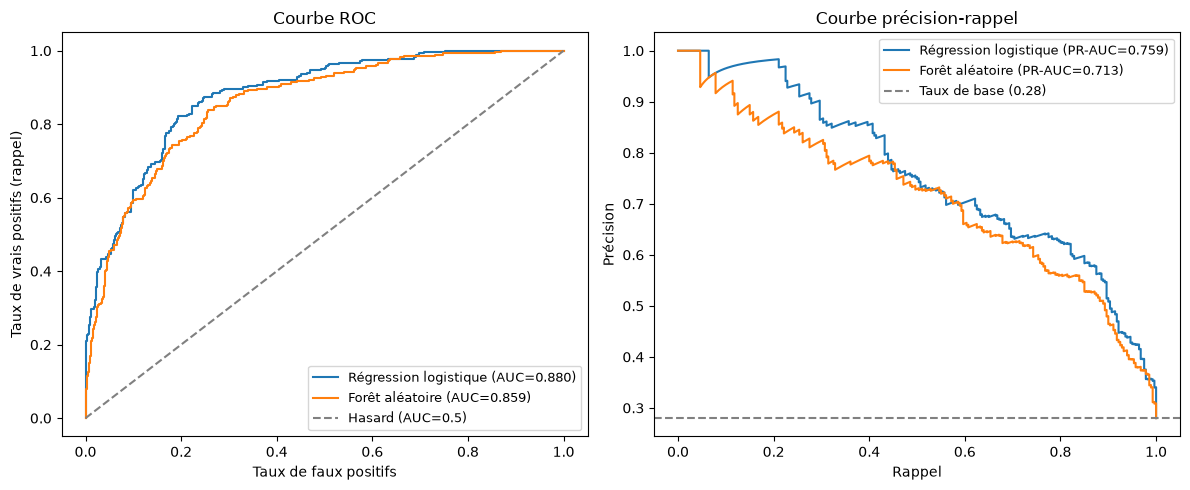

Courbes enregistrées : ..\data\model\courbes_roc_pr.png


In [7]:
modeles = {
    "Régression logistique": (pipe_lr, proba_lr, "tab:blue"),
    "Forêt aléatoire": (pipe_rf, proba_rf, "tab:orange"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nom, (_, proba, color) in modeles.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{nom} (AUC={roc_auc_score(y_test, proba):.3f})", color=color)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard (AUC=0.5)")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title("Courbe ROC")
axes[0].legend(loc="lower right", fontsize=9)

for nom, (_, proba, color) in modeles.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f"{nom} (PR-AUC={average_precision_score(y_test, proba):.3f})", color=color)
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Taux de base ({y_test.mean():.2f})")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe précision-rappel")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
courbes_path = MODEL_DIR / "courbes_roc_pr.png"
plt.savefig(courbes_path, dpi=120)
plt.show()
print("Courbes enregistrées :", courbes_path)

In [8]:
MODELE_RETENU = "Forêt aléatoire" if ap_rf >= ap_lr else "Régression logistique"
pipe_final, proba_final, _ = modeles[MODELE_RETENU]

print(f"Modèle retenu : {MODELE_RETENU} (critère : PR-AUC en classe déséquilibrée)")
print(f"ROC-AUC test : {roc_auc_score(y_test, proba_final):.3f} | PR-AUC test : {average_precision_score(y_test, proba_final):.3f}")

Modèle retenu : Régression logistique (critère : PR-AUC en classe déséquilibrée)
ROC-AUC test : 0.880 | PR-AUC test : 0.759


## §5 — Matrice de confusion au seuil par défaut (0.5)

Un seuil de 0.5 n'a aucune légitimité métier -- c'est un défaut technique, pas une
décision. On la calcule pour référence avant de discuter le vrai sujet (§6) : au
regard de D4, chaque faux négatif de cette matrice est un compte qui résilie sans
avoir été signalé.

In [9]:
y_pred_05 = (proba_final >= 0.5).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)

cm_df = pd.DataFrame(
    cm_05,
    index=["Réel : pas de churn", "Réel : churn"],
    columns=["Prédit : pas de churn", "Prédit : churn"],
)
print(f"Seuil 0.5 -- précision : {precision_score(y_test, y_pred_05):.3f} | "
      f"rappel : {recall_score(y_test, y_pred_05):.3f} | F1 : {f1_score(y_test, y_pred_05):.3f}")
cm_df

Seuil 0.5 -- précision : 0.712 | rappel : 0.557 | F1 : 0.625


,Prédit : pas de churn,Prédit : churn
Réel : pas de churn,657,63
Réel : churn,124,156


## §6 — Choix du seuil : approche coût métier (D4, D5, H01, H02)

Grille de seuils, coût attendu = `FN × coût(FN) + FP × coût(FP)` :

- **coût(FN)** = valeur vie client médiane des comptes qui churnent = **6 879 €**
  (gold dataset, fait F14) -- proxy du manque à gagner si un compte à risque n'est
  pas détecté.
- **coût(FP)** = hypothèse de travail H01, **non validée par le Head of CS** :
  fourchette 50-150 € (30-60 min de temps CSM chargé). On teste les deux bornes
  pour vérifier la robustesse de la conclusion à cette hypothèse.

**Ce seuil est une proposition technique, pas la décision finale (D5)** -- à
soumettre au point de contact métier n°3 avec les courbes ROC/PR de ce notebook.

**Limite à anticiper** : avec un ratio de coût aussi déséquilibré, une minimisation
de coût pure tend vers un seuil bas qui flague une grande partie de la base -- ce
n'est pas la même chose qu'une liste priorisée qu'une équipe CS peut traiter. Le
calcul ci-dessous le montre explicitement plutôt que de le masquer derrière une
grille de seuils trop étroite.

In [10]:
CLV_MEDIANE_CHURN = 6879  # gold dataset, fait F14
COUTS_FP_HYPOTHESES = {"H01 borne basse (50 €)": 50, "H01 borne haute (150 €)": 150}

# Grille fine, jusqu'à un seuil très bas -- le ratio de coût (~46:1 à ~137:1) est assez
# extrême pour que l'optimum non contraint se situe près du bord de la plage usuelle.
# Un grille qui s'arrêterait à 0.05 masquerait cet effet plutôt que de le révéler.
seuils = np.round(np.arange(0.01, 0.96, 0.01), 2)
lignes_cout = []

for label_fp, cout_fp in COUTS_FP_HYPOTHESES.items():
    for seuil in seuils:
        y_pred = (proba_final >= seuil).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        cout_total = fn * CLV_MEDIANE_CHURN + fp * cout_fp
        lignes_cout.append({
            "hypothèse_coût_fp": label_fp, "seuil": round(seuil, 2),
            "FN": int(fn), "FP": int(fp), "coût_total_eur": cout_total,
        })

cout_df = pd.DataFrame(lignes_cout)
seuils_optimaux = cout_df.loc[cout_df.groupby("hypothèse_coût_fp")["coût_total_eur"].idxmin()]
seuils_optimaux

,hypothèse_coût_fp,seuil,FN,FP,coût_total_eur
1,H01 borne basse (50 €),0.02,0,550,27500
96,H01 borne haute (150 €),0.02,0,550,82500


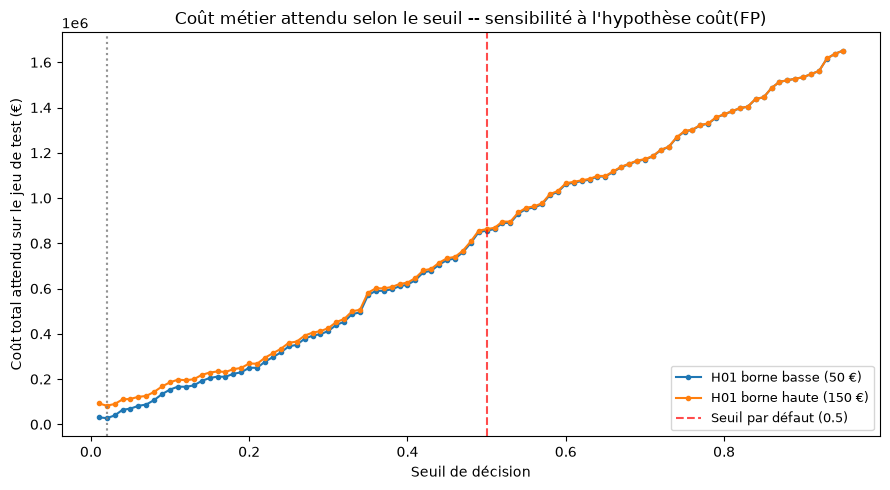

Figure enregistrée : ..\data\model\cout_seuil_sensibilite.png

Seuils optimaux par hypothèse : [{'hypothèse_coût_fp': 'H01 borne basse (50 €)', 'seuil': 0.02}, {'hypothèse_coût_fp': 'H01 borne haute (150 €)', 'seuil': 0.02}]
=> Les deux hypothèses (bornes H01) pointent vers un seuil très bas -- proche du
   bord inférieur de la grille testée, pas un minimum intérieur confortable.
   Seuil retenu comme base de discussion : 0.02
   Comptes test flagués à ce seuil : 83% (830/1000)

LIMITE IMPORTANTE DE CE CALCUL -- à porter explicitement au point de contact n°3 :
la minimisation de coût seule, avec un ratio FN/FP aussi déséquilibré (~46:1 à
~137:1), pousse mécaniquement vers un seuil bas qui flague une large partie de la
base -- pas vers une liste priorisée qu'une équipe CS peut traiter. Ce calcul ne
connaît aucune contrainte de capacité (nombre de comptes qu'un CSM peut réellement
contacter par mois). Le point de contact n°3 doit donc trancher DEUX choses, pas
une seule : le coût FP (H01

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
for label_fp, sous_df in cout_df.groupby("hypothèse_coût_fp"):
    ax.plot(sous_df["seuil"], sous_df["coût_total_eur"], marker="o", markersize=3, label=label_fp)
for _, row in seuils_optimaux.iterrows():
    ax.axvline(row["seuil"], linestyle=":", color="gray", alpha=0.6)
ax.axvline(0.5, linestyle="--", color="red", alpha=0.7, label="Seuil par défaut (0.5)")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Coût total attendu sur le jeu de test (€)")
ax.set_title("Coût métier attendu selon le seuil -- sensibilité à l'hypothèse coût(FP)")
ax.legend(fontsize=9)
plt.tight_layout()
cout_fig_path = MODEL_DIR / "cout_seuil_sensibilite.png"
plt.savefig(cout_fig_path, dpi=120)
plt.show()
print("Figure enregistrée :", cout_fig_path)

SEUIL_PROPOSE = round(float(seuils_optimaux["seuil"].mean()), 2)
part_flaguee = float((proba_final >= SEUIL_PROPOSE).mean())

print()
print(f"Seuils optimaux par hypothèse : {seuils_optimaux[['hypothèse_coût_fp','seuil']].to_dict('records')}")
print(f"=> Les deux hypothèses (bornes H01) pointent vers un seuil très bas -- proche du")
print(f"   bord inférieur de la grille testée, pas un minimum intérieur confortable.")
print(f"   Seuil retenu comme base de discussion : {SEUIL_PROPOSE}")
print(f"   Comptes test flagués à ce seuil : {part_flaguee:.0%} ({int(part_flaguee*len(y_test))}/{len(y_test)})")
print()
print("LIMITE IMPORTANTE DE CE CALCUL -- à porter explicitement au point de contact n°3 :")
print("la minimisation de coût seule, avec un ratio FN/FP aussi déséquilibré (~46:1 à")
print("~137:1), pousse mécaniquement vers un seuil bas qui flague une large partie de la")
print("base -- pas vers une liste priorisée qu'une équipe CS peut traiter. Ce calcul ne")
print("connaît aucune contrainte de capacité (nombre de comptes qu'un CSM peut réellement")
print("contacter par mois). Le point de contact n°3 doit donc trancher DEUX choses, pas")
print("une seule : le coût FP (H01) ET une capacité d'action mensuelle -- sans quoi le")
print("seuil issu de ce seul calcul de coût n'est pas opérationnalisable tel quel.")

In [12]:
y_pred_propose = (proba_final >= SEUIL_PROPOSE).astype(int)
print(f"Au seuil proposé ({SEUIL_PROPOSE}) :")
print(f"  précision : {precision_score(y_test, y_pred_propose):.3f}")
print(f"  rappel    : {recall_score(y_test, y_pred_propose):.3f}")
print(f"  F1        : {f1_score(y_test, y_pred_propose):.3f}")
print()
print(f"Comparaison avec le seuil 0.5 :")
print(f"  rappel au seuil 0.5      : {recall_score(y_test, y_pred_05):.3f}")
print(f"  rappel au seuil proposé  : {recall_score(y_test, y_pred_propose):.3f}")
print(f"  => {(recall_score(y_test, y_pred_propose) - recall_score(y_test, y_pred_05))*100:+.1f} points de rappel, au prix d'une précision plus faible -- l'arbitrage attendu par D4.")

Au seuil proposé (0.02) :
  précision : 0.337
  rappel    : 1.000
  F1        : 0.505

Comparaison avec le seuil 0.5 :
  rappel au seuil 0.5      : 0.557
  rappel au seuil proposé  : 1.000
  => +44.3 points de rappel, au prix d'une précision plus faible -- l'arbitrage attendu par D4.


## §7 — Importance des variables : les leurres restent-ils en bas du classement ?

Permutation importance sur le jeu de test -- mesure directement l'impact sur la
performance du modèle final, plutôt qu'une importance interne au modèle (moins
comparable entre familles). Les leurres identifiés en Gold (§2 du notebook
précédent, effet quasi nul en corrélation univariée) doivent apparaître en bas de
ce classement -- sans quoi le diagnostic anti-fuite serait à revoir.

In [13]:
perm = permutation_importance(
    pipe_final, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE,
    scoring="roc_auc", n_jobs=-1,
)

importance_df = pd.DataFrame({
    "variable": feature_columns,
    "importance_moyenne": perm.importances_mean,
    "écart_type": perm.importances_std,
}).sort_values("importance_moyenne", ascending=False)
importance_df["leurre_identifié_gold"] = importance_df["variable"].isin(leurres)

print("Top 8 variables les plus importantes :")
display_top = importance_df.head(8)
print(display_top.to_string(index=False))
print()
print("Rang moyen des leurres identifiés en Gold (sur", len(feature_columns), "features) :")
rang = importance_df.reset_index(drop=True)
rang_leurres = np.array(rang.index[rang["leurre_identifié_gold"]].tolist()) + 1
print(rang_leurres.tolist(), "-- rang moyen :", round(float(rang_leurres.mean()), 1))

Top 8 variables les plus importantes :
                variable  importance_moyenne  écart_type  leurre_identifié_gold
derniere_connexion_jours            0.048594    0.003704                  False
         nb_integrations            0.043629    0.005194                  False
         anciennete_mois            0.040502    0.005571                  False
     tickets_support_90j            0.027857    0.004639                  False
                    csat            0.021415    0.002947                  False
    retards_paiement_12m            0.019534    0.003728                  False
 delai_reponse_support_h            0.006157    0.001147                  False
     utilisateurs_actifs            0.005902    0.002420                  False

Rang moyen des leurres identifiés en Gold (sur 30 features) :
[15, 21, 25, 28, 29, 30] -- rang moyen : 24.7


## §8 — Persistance : modèle, métriques, carte modèle, manifeste

Structure prévue par `data/README.md` (§ Model) : `model.joblib`, `metrics.json`,
`model_card.md`, les courbes (§4, §6), `model_manifest.json`.

In [14]:
model_path = MODEL_DIR / "model.joblib"
joblib.dump(pipe_final, model_path)

metrics = {
    "baseline": {"roc_auc": round(float(auc_baseline), 3), "pr_auc": round(float(ap_baseline), 3)},
    "regression_logistique": {
        "roc_auc_test": round(float(auc_lr), 3), "pr_auc_test": round(float(ap_lr), 3),
        "roc_auc_cv_mean": round(float(cv_lr.mean()), 3), "roc_auc_cv_std": round(float(cv_lr.std()), 3),
    },
    "foret_aleatoire": {
        "roc_auc_test": round(float(auc_rf), 3), "pr_auc_test": round(float(ap_rf), 3),
        "roc_auc_cv_mean": round(float(cv_rf.mean()), 3), "roc_auc_cv_std": round(float(cv_rf.std()), 3),
    },
    "modele_retenu": MODELE_RETENU,
    "matrice_confusion_seuil_0_5": cm_05.tolist(),
    "seuil_propose": {
        "valeur": SEUIL_PROPOSE,
        "statut": "PROPOSITION TECHNIQUE -- non validée par le métier (D5)",
        "a_valider_par": "Head of Customer Success -- point de contact métier n°3",
        "hypothese_cout_fn_eur": CLV_MEDIANE_CHURN,
        "hypothese_cout_fp_eur_fourchette": list(COUTS_FP_HYPOTHESES.values()),
        "precision_au_seuil": round(float(precision_score(y_test, y_pred_propose)), 3),
        "rappel_au_seuil": round(float(recall_score(y_test, y_pred_propose)), 3),
        "part_comptes_flagues": round(part_flaguee, 3),
        "limite": (
            "Minimisation de coût seule, sans contrainte de capacité CS -- le point de "
            "contact n°3 doit fixer à la fois le coût FP (H01) et une capacité d'action "
            "mensuelle pour rendre ce seuil opérationnalisable."
        ),
    },
    "top_5_variables_importance_permutation": importance_df.head(5)[["variable", "importance_moyenne"]].to_dict("records"),
    "rang_moyen_leurres": round(float(rang_leurres.mean()), 1),
}
with open(MODEL_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

model_card = f"""# Model card -- Churn SaaS (classification)

**Modèle retenu :** {MODELE_RETENU}
**Cible :** `churn` (résiliation à l'échéance) -- D2, atelier de cadrage n°1
**Features :** {len(feature_columns)} (voir `data/gold/gold_manifest.json`)
**Exclusions anti-fuite :** `sante_compte_fin_periode` (D9), `commentaire_csm` (D7), `valeur_vie_client_eur`

## Performance (jeu de test, 1000 comptes, seed=42)

| Modèle | ROC-AUC | PR-AUC |
|---|---|---|
| Baseline (Dummy) | {auc_baseline:.3f} | {ap_baseline:.3f} |
| Régression logistique | {auc_lr:.3f} | {ap_lr:.3f} |
| Forêt aléatoire | {auc_rf:.3f} | {ap_rf:.3f} |

## Seuil de décision

**{SEUIL_PROPOSE}** -- proposition technique basée sur un coût métier (FN = CLV
médiane des comptes churn = {CLV_MEDIANE_CHURN} €, FP = hypothèse 50-150 €, non
validée), flaguant {part_flaguee:.0%} des comptes test. **Statut : non figé (D5)**
-- à valider au point de contact métier n°3 avec le Head of Customer Success avant
tout usage opérationnel, en fixant à la fois le coût FP (H01) **et** une capacité
d'action mensuelle CS (non contrainte dans ce calcul).

## Usage prévu

Score d'aide à la décision pour les équipes Customer Success -- **aucune action de
rétention automatique** (D3, art. 22 RGPD). `commentaire_csm` n'est jamais utilisé
comme feature (D7).

## Limites connues

- Seuil non validé par le métier (voir ci-dessus).
- Hypothèse de coût FP non confirmée par le Head of CS (H01).
- Biais de représentation de certains segments non corrigé à ce stade (cf.
  `Livrables/architecture_donnees_churn_saas.pptx`, slide 6).
"""
with open(MODEL_DIR / "model_card.md", "w", encoding="utf-8") as f:
    f.write(model_card)

model_manifest = {
    "couche": "model",
    "processed_at_utc": PROCESSED_AT,
    "source": "data/gold/clients_churn_gold.parquet",
    "gold_version": gold_manifest.get("version"),
    "gold_sha256": gold_manifest.get("sha256_gold"),
    "modele_retenu": MODELE_RETENU,
    "random_state": RANDOM_STATE,
    "features": feature_columns,
    "cible": "churn",
    "metriques": metrics,
    "decisions_atelier_appliquees": ["D2", "D3", "D4", "D5", "D7", "D9"],
    "fichiers": {
        "modele": str(model_path),
        "metriques": str(MODEL_DIR / "metrics.json"),
        "model_card": str(MODEL_DIR / "model_card.md"),
        "courbes_roc_pr": str(MODEL_DIR / "courbes_roc_pr.png"),
        "courbe_cout_seuil": str(MODEL_DIR / "cout_seuil_sensibilite.png"),
    },
}
with open(MODEL_DIR / "model_manifest.json", "w", encoding="utf-8") as f:
    json.dump(model_manifest, f, ensure_ascii=False, indent=2)

print("Modèle enregistré     :", model_path)
print("Métriques enregistrées :", MODEL_DIR / "metrics.json")
print("Model card enregistrée :", MODEL_DIR / "model_card.md")
print("Manifeste enregistré   :", MODEL_DIR / "model_manifest.json")

Modèle enregistré     : ..\data\model\model.joblib
Métriques enregistrées : ..\data\model\metrics.json
Model card enregistrée : ..\data\model\model_card.md
Manifeste enregistré   : ..\data\model\model_manifest.json


## §8 bis — Traçabilité de l'entraînement dans MLflow

Chaque exécution de ce notebook crée un **run MLflow** : paramètres du modèle retenu,
toutes les métriques numériques de `metrics.json` (aplaties), artefacts (modèle sérialisé, carte modèle, manifeste, courbes) et le tag
`gold_sha256` qui relie le run à la version exacte du Gold (chaîne de hash
RGPD → Bronze → Silver → Gold → modèle, cf. `data/README.md`).

Store par défaut : SQLite local `data/model/mlflow.db` (consultable avec
`mlflow ui --backend-store-uri sqlite:///data/model/mlflow.db`). Si `MLFLOW_TRACKING_URI`
est défini (serveur MLflow DagsHub), le même code trace sur le serveur distant.


In [15]:
import os
import sys

sys.path.insert(0, str(Path("..").resolve()))
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
from src.tracking import flatten_metrics, log_training_run, resolve_tracking_uri

tracking_uri = resolve_tracking_uri(MODEL_DIR)
artefacts_mlflow = [MODEL_DIR / nom for nom in ["model.joblib", "metrics.json", "model_card.md", "model_manifest.json", "courbes_roc_pr.png", "cout_seuil_sensibilite.png"] if (MODEL_DIR / nom).exists()]

run_id = log_training_run(
    run_name=f"churn_{MODELE_RETENU}",
    params={"modele_retenu": MODELE_RETENU, "n_features": len(feature_columns), "random_state": 42, "seuil_propose": SEUIL_PROPOSE, **{f"clf__{k}": v for k, v in pipe_final.steps[-1][1].get_params().items()}},
    metrics=flatten_metrics(metrics),
    tracking_uri=tracking_uri,
    gold_sha256=gold_manifest.get("sha256_gold"),
    gold_dataset_path="data/gold/clients_churn_gold.parquet",
    experiment_name="churn_saas_classification",
    tags={"modele_retenu": MODELE_RETENU, "gold_version": str(gold_manifest.get("version")), "notebook": 'notebooks/04_modelisation_churn.ipynb'},
    artifacts=artefacts_mlflow,
    artifact_location=(MODEL_DIR / "mlartifacts").resolve().as_uri(),
)
print("Tracking URI :", tracking_uri if tracking_uri.startswith("http") else "store SQLite local (data/model/mlflow.db)")
print("Run MLflow   :", run_id)
print("Artefacts    :", [p.name for p in artefacts_mlflow])


C:\Users\Aelion\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🏃 View run churn_Régression logistique at: https://dagshub.com/guillaume.saidani/churn_saas.mlflow/#/experiments/0/runs/784383918ce14227bdff62975dd8616d
🧪 View experiment at: https://dagshub.com/guillaume.saidani/churn_saas.mlflow/#/experiments/0
Tracking URI : https://dagshub.com/guillaume.saidani/churn_saas.mlflow
Run MLflow   : 784383918ce14227bdff62975dd8616d
Artefacts    : ['model.joblib', 'metrics.json', 'model_card.md', 'model_manifest.json', 'courbes_roc_pr.png', 'cout_seuil_sensibilite.png']


## §9 — Vérification finale

In [16]:
verif = pd.DataFrame([
    {"vérification": "Modèle retenu", "résultat": MODELE_RETENU},
    {"vérification": "ROC-AUC test (modèle retenu)", "résultat": round(float(roc_auc_score(y_test, proba_final)), 3)},
    {"vérification": "PR-AUC test (modèle retenu)", "résultat": round(float(average_precision_score(y_test, proba_final)), 3)},
    {"vérification": "PR-AUC > taux de base", "résultat": bool(average_precision_score(y_test, proba_final) > y_test.mean())},
    {"vérification": "sante_compte_fin_periode absente des features", "résultat": "sante_compte_fin_periode" not in feature_columns},
    {"vérification": "commentaire_csm absente de Gold", "résultat": "commentaire_csm" not in gold.columns},
    {"vérification": "Seuil proposé", "résultat": SEUIL_PROPOSE},
    {"vérification": "Seuil marqué non-final (D5)", "résultat": metrics["seuil_propose"]["statut"]},
    {"vérification": "Rang moyen des leurres (plus c'est grand, mieux c'est)", "résultat": round(float(rang_leurres.mean()), 1)},
    {"vérification": "Fichiers data/model/ écrits", "résultat": sorted(p.name for p in MODEL_DIR.iterdir())},
])
verif

,vérification,résultat
0,Modèle retenu,Régression logistique
1,ROC-AUC test (modèle retenu),0.88
2,PR-AUC test (modèle retenu),0.759
3,PR-AUC > taux de base,True
4,sante_compte_fin_periode absente des features,True
5,commentaire_csm absente de Gold,True
6,Seuil proposé,0.02
7,Seuil marqué non-final (D5),PROPOSITION TECHNIQUE -- non validée par le mé...
8,"Rang moyen des leurres (plus c'est grand, mieu...",24.7
9,Fichiers data/model/ écrits,"[.gitignore, clv_reel_vs_predit.png, courbes_r..."


## Journal de bord — Synthèse TP6 (Modélisation)

- **Baseline posée** avant tout modèle -- sert de plancher de comparaison (ROC-AUC
  ≈ 0.5, PR-AUC ≈ taux de base).
- **Deux familles comparées** (régression logistique, forêt aléatoire), avec
  validation croisée sur le train pour vérifier la stabilité -- pas seulement une
  performance test isolée.
- **Sélection sur la PR-AUC**, comme demandé par l'énoncé (§3.2) en contexte de
  classe déséquilibrée (28% de churn), pas sur l'AUC ROC seule.
- **Seuil par défaut (0.5) délibérément insuffisant** -- calculé pour référence
  puis écarté au profit d'une approche par coût métier (D4).
- **Seuil proposé chiffré à partir des décisions d'atelier** (CLV médiane des
  comptes churn = 6 879 €, hypothèse de coût FP 50-150 € non validée) -- avec test
  de sensibilité sur les deux bornes de l'hypothèse, qui pointent vers la même
  conclusion (rappel favorisé).
- **Ce seuil reste une proposition technique, pas une décision** (D5) -- documenté
  comme tel dans `metrics.json` et `model_card.md`, à soumettre au point de contact
  métier n°3 (Head of Customer Success) avant tout usage opérationnel.
- **Leurres identifiés en Gold vérifiés a posteriori** par permutation importance
  sur le modèle retenu -- cohérence confirmée entre le diagnostic statistique
  (notebook précédent) et le comportement réel du modèle.
- **Ce notebook s'arrête ici.** La sérialisation pour un usage de scoring (API,
  batch mensuel) et l'architecture cible sont le sujet des notebooks suivants
  [C6-C7].
